DATASET SHAPE
(1000, 12)

FIRST 5 ROWS
   StudentID     Name  Gender  AttendanceRate  StudyHoursPerWeek  \
0        1.0     John    Male            85.0               15.0   
1        2.0    Sarah  Female            90.0               20.0   
2        3.0     Alex    Male            78.0               10.0   
3        4.0  Michael    Male            92.0               25.0   
4        5.0     Emma  Female             NaN               18.0   

   PreviousGrade  ExtracurricularActivities ParentalSupport  FinalGrade  \
0           78.0                        1.0            High        80.0   
1           85.0                        2.0          Medium        87.0   
2           65.0                        0.0             Low        68.0   
3           90.0                        3.0            High        92.0   
4           82.0                        2.0          Medium        85.0   

   Study Hours  Attendance (%) Online Classes Taken  
0          4.8            59.0                F

/tmp/ipykernel_15054/966700366.py:47: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


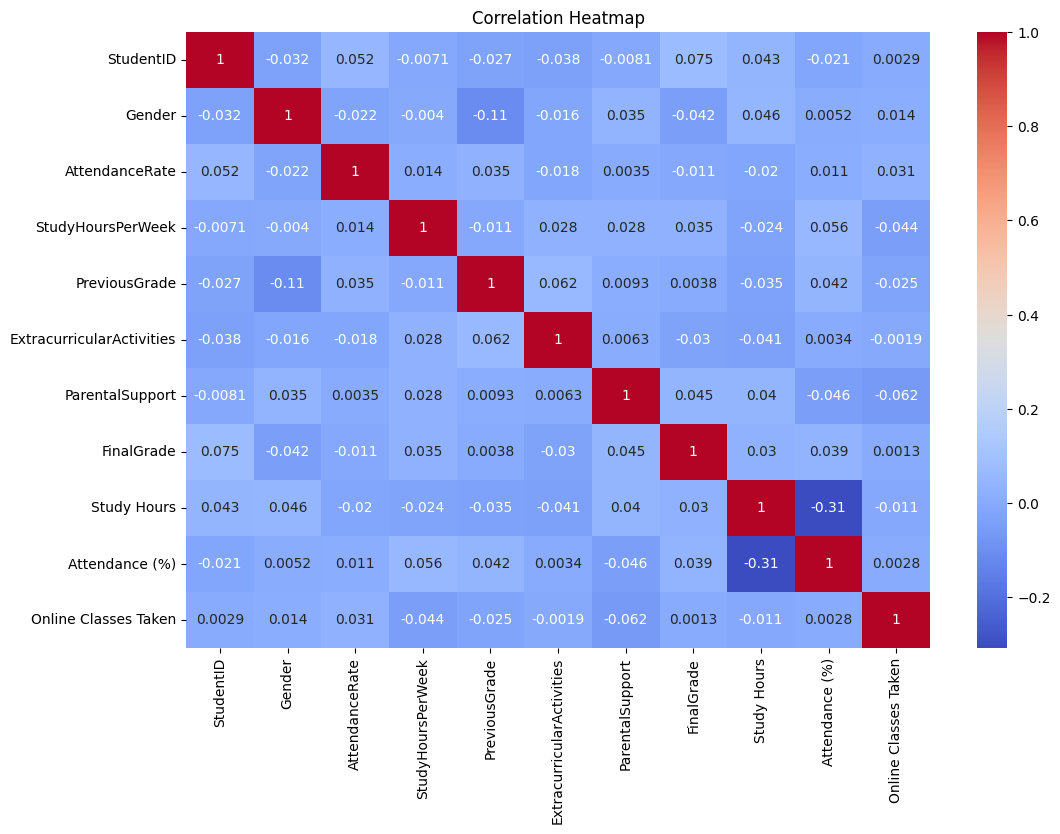

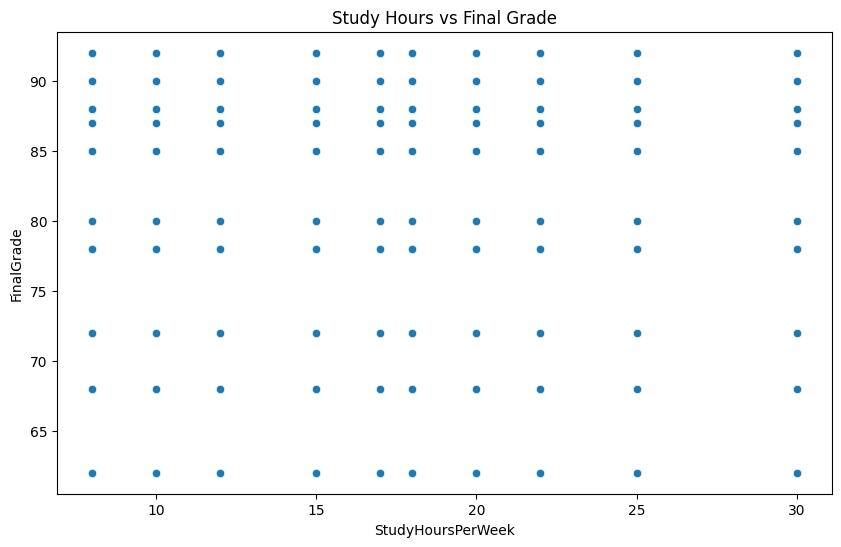

ValueError: Could not interpret value `AttendenceRate` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

In [1]:
# ==========================================
# WEEK 3 - EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create folders if not exist
os.makedirs("visuals", exist_ok=True)

# Load Dataset
df = pd.read_csv("dataset/student_performance.csv")

print("="*50)
print("DATASET SHAPE")
print("="*50)
print(df.shape)

print("\nFIRST 5 ROWS")
print(df.head())

# ==========================================
# BASIC INFORMATION
# ==========================================

print("\nDATASET INFO")
print(df.info())

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nSTATISTICAL SUMMARY")
print(df.describe())

# ==========================================
# DATA CLEANING
# ==========================================

df = df.drop_duplicates()

# Fill missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

print("\nAFTER CLEANING")
print(df.isnull().sum())

# ==========================================
# ENCODE CATEGORICAL COLUMNS
# ==========================================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = [
    'Gender',
    'ExtracurricularActivities',
    'ParentalSupport'
]

for col in categorical_columns:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])

# ==========================================
# CORRELATION HEATMAP
# ==========================================

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.savefig(
    "visuals/correlation_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ==========================================
# STUDY HOURS VS FINAL GRADE
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='StudyHoursPerWeek',
    y='FinalGrade',
    data=df
)

plt.title("Study Hours vs Final Grade")

plt.savefig(
    "visuals/study_hours_vs_grade.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ==========================================
# ATTENDANCE VS FINAL GRADE
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='AttendenceRate',
    y='FinalGrade',
    data=df
)

plt.title("Attendance vs Final Grade")

plt.savefig(
    "visuals/attendance_vs_grade.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ==========================================
# GRADE DISTRIBUTION
# ==========================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['FinalGrade'],
    bins=20,
    kde=True
)

plt.title("Final Grade Distribution")

plt.savefig(
    "visuals/grade_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ==========================================
# PARENTAL SUPPORT ANALYSIS
# ==========================================

plt.figure(figsize=(10,6))

sns.boxplot(
    x='ParentalSupport',
    y='FinalGrade',
    data=df
)

plt.title("Parental Support vs Final Grade")

plt.savefig(
    "visuals/parental_support_analysis.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ==========================================
# EXTRA VISUALIZATION
# ==========================================

plt.figure(figsize=(10,6))

sns.boxplot(
    x='Gender',
    y='FinalGrade',
    data=df
)

plt.title("Gender vs Final Grade")

plt.savefig(
    "visuals/gender_vs_grade.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ==========================================
# INSIGHTS
# ==========================================

print("\n" + "="*50)
print("KEY INSIGHTS")
print("="*50)

corr = df.corr(numeric_only=True)

if 'FinalGrade' in corr.columns:
    print("\nTop Correlations With FinalGrade:")
    print(
        corr['FinalGrade']
        .sort_values(ascending=False)
        .head(10)
    )

print("\nEDA COMPLETED SUCCESSFULLY")
print("\nGenerated Files:")

for file in os.listdir("visuals"):
    print(file)

In [2]:
print(df.columns.tolist())

['StudentID', 'Name', 'Gender', 'AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport', 'FinalGrade', 'Study Hours', 'Attendance (%)', 'Online Classes Taken']


DATASET SHAPE
(1000, 12)

FIRST 5 ROWS
   StudentID     Name  Gender  AttendanceRate  StudyHoursPerWeek  \
0        1.0     John    Male            85.0               15.0   
1        2.0    Sarah  Female            90.0               20.0   
2        3.0     Alex    Male            78.0               10.0   
3        4.0  Michael    Male            92.0               25.0   
4        5.0     Emma  Female             NaN               18.0   

   PreviousGrade  ExtracurricularActivities ParentalSupport  FinalGrade  \
0           78.0                        1.0            High        80.0   
1           85.0                        2.0          Medium        87.0   
2           65.0                        0.0             Low        68.0   
3           90.0                        3.0            High        92.0   
4           82.0                        2.0          Medium        85.0   

   Study Hours  Attendance (%) Online Classes Taken  
0          4.8            59.0                F

/tmp/ipykernel_15054/772598995.py:56: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


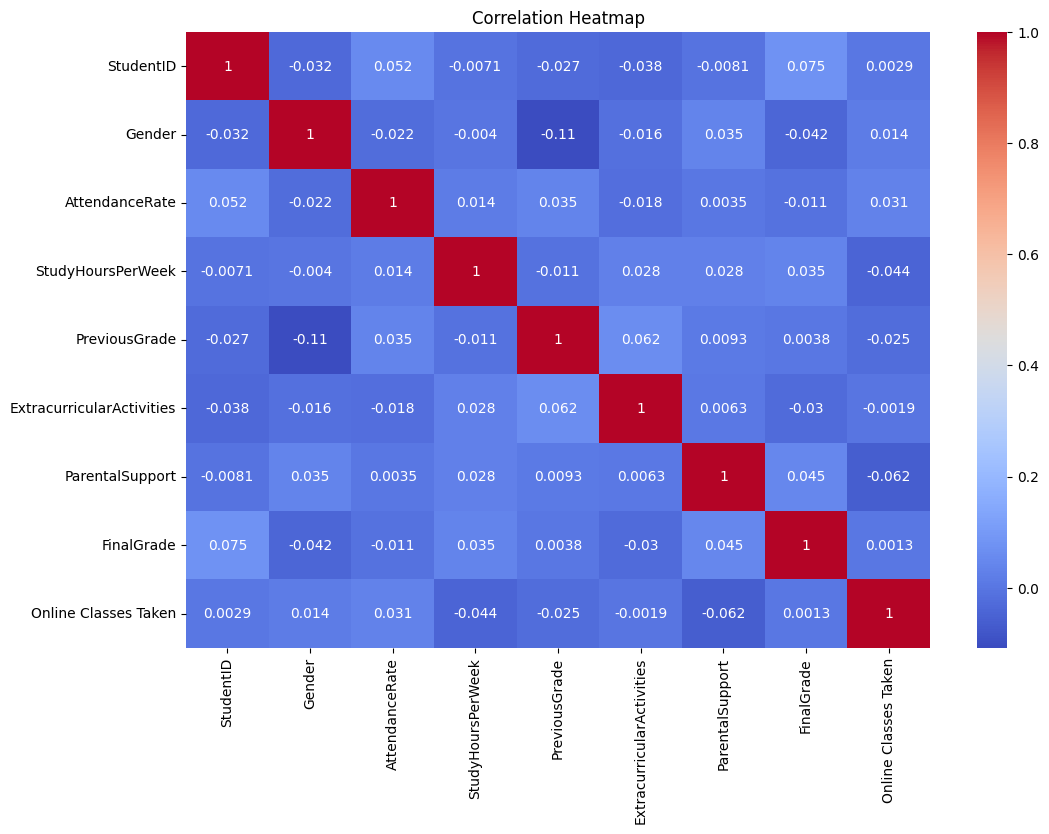

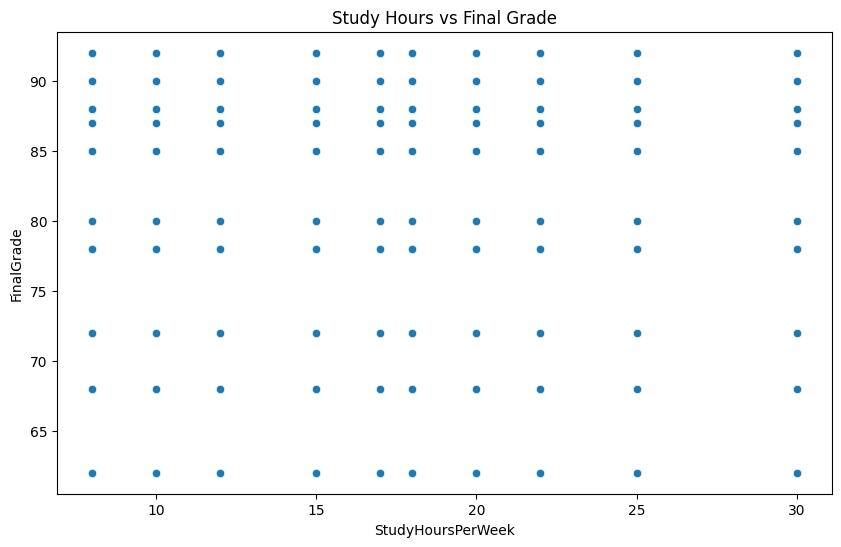

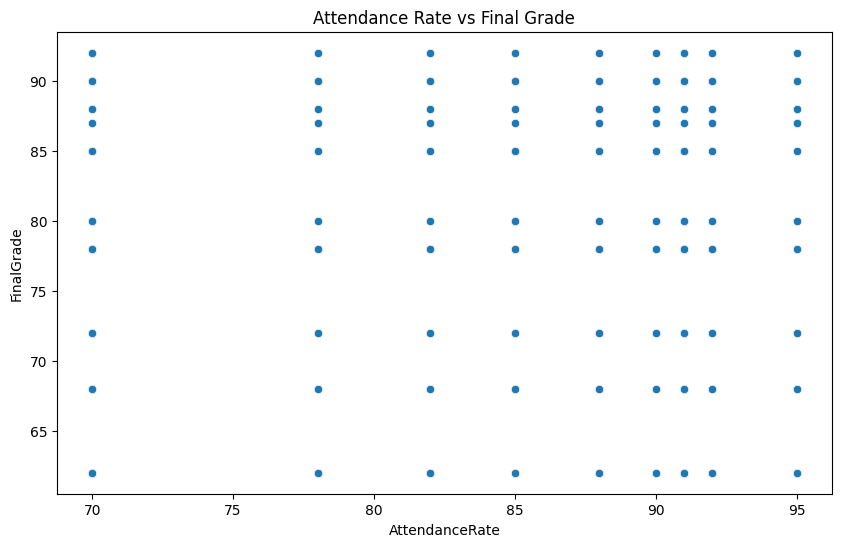

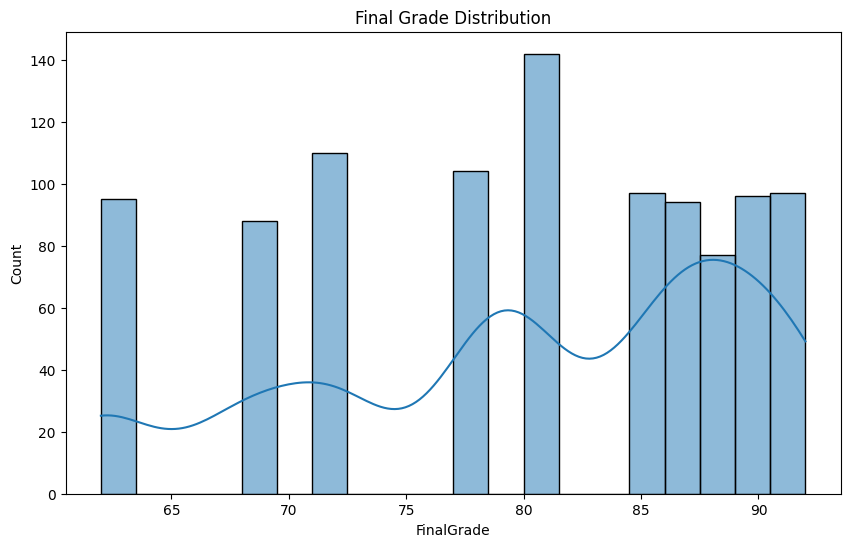

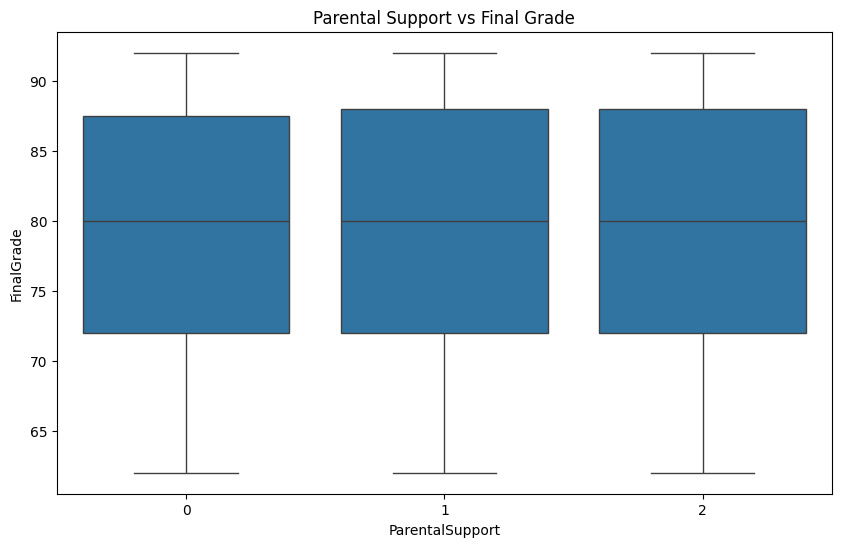

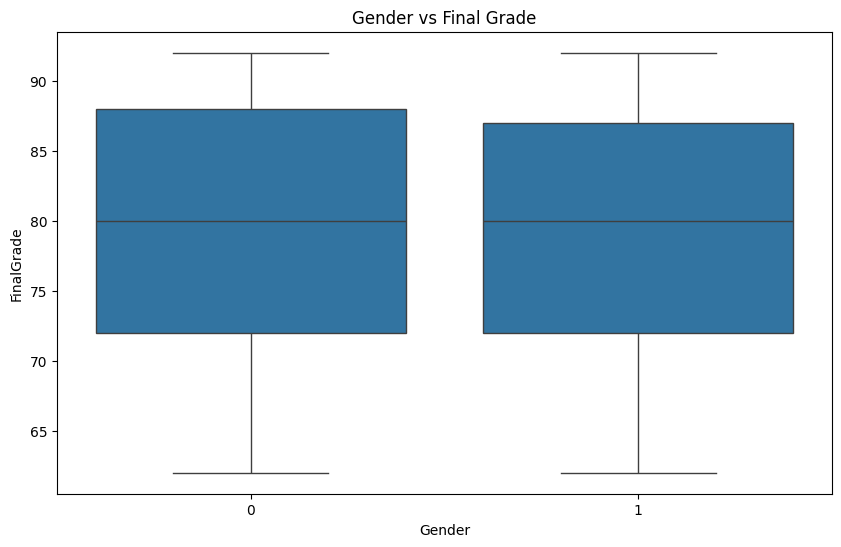

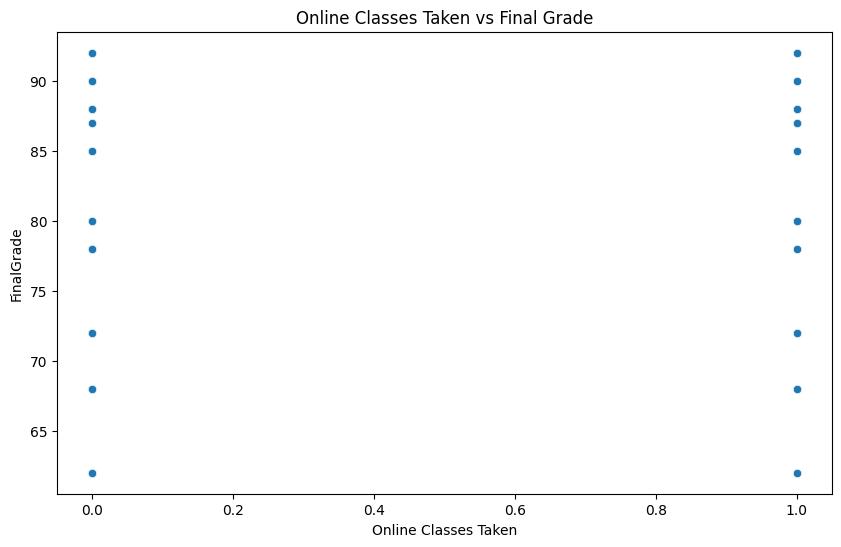


CORRELATION WITH FINAL GRADE
FinalGrade                   1.000000
StudentID                    0.075247
ParentalSupport              0.044837
StudyHoursPerWeek            0.034574
PreviousGrade                0.003830
Online Classes Taken         0.001275
AttendanceRate              -0.011115
ExtracurricularActivities   -0.030163
Gender                      -0.041919
Name: FinalGrade, dtype: float64

EDA COMPLETED SUCCESSFULLY

Generated Visuals:
✓ attendance_vs_grade.png
✓ study_hours_vs_grade.png
✓ online_classes_vs_grade.png
✓ correlation_heatmap.png
✓ parental_support_analysis.png
✓ gender_vs_grade.png
✓ grade_distribution.png

Cleaned dataset saved as:
student_performance_cleaned.csv


In [3]:
# ==========================================
# WEEK 3 - EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder

# ==========================================
# CREATE FOLDERS
# ==========================================

os.makedirs("visuals", exist_ok=True)

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("dataset/student_performance.csv")

print("="*50)
print("DATASET SHAPE")
print("="*50)
print(df.shape)

print("\nFIRST 5 ROWS")
print(df.head())

print("\nCOLUMN NAMES")
print(df.columns.tolist())

# ==========================================
# BASIC INFORMATION
# ==========================================

print("\nDATASET INFO")
print(df.info())

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nSTATISTICAL SUMMARY")
print(df.describe())

# ==========================================
# DATA CLEANING
# ==========================================

df.drop_duplicates(inplace=True)

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

print("\nAFTER CLEANING")
print(df.isnull().sum())

# ==========================================
# REMOVE DUPLICATE COLUMNS
# ==========================================

drop_cols = []

if "Study Hours" in df.columns:
    drop_cols.append("Study Hours")

if "Attendance (%)" in df.columns:
    drop_cols.append("Attendance (%)")

df.drop(columns=drop_cols, inplace=True)

# ==========================================
# ENCODE CATEGORICAL COLUMNS
# ==========================================

le = LabelEncoder()

categorical_cols = [
    "Gender",
    "ExtracurricularActivities",
    "ParentalSupport"
]

for col in categorical_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])

# ==========================================
# CORRELATION HEATMAP
# ==========================================

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "visuals/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================
# STUDY HOURS VS FINAL GRADE
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x="StudyHoursPerWeek",
    y="FinalGrade",
    data=df
)

plt.title("Study Hours vs Final Grade")

plt.savefig(
    "visuals/study_hours_vs_grade.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================
# ATTENDANCE VS FINAL GRADE
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x="AttendanceRate",
    y="FinalGrade",
    data=df
)

plt.title("Attendance Rate vs Final Grade")

plt.savefig(
    "visuals/attendance_vs_grade.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================
# FINAL GRADE DISTRIBUTION
# ==========================================

plt.figure(figsize=(10,6))

sns.histplot(
    df["FinalGrade"],
    bins=20,
    kde=True
)

plt.title("Final Grade Distribution")

plt.savefig(
    "visuals/grade_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================
# PARENTAL SUPPORT ANALYSIS
# ==========================================

plt.figure(figsize=(10,6))

sns.boxplot(
    x="ParentalSupport",
    y="FinalGrade",
    data=df
)

plt.title("Parental Support vs Final Grade")

plt.savefig(
    "visuals/parental_support_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================
# GENDER VS FINAL GRADE
# ==========================================

plt.figure(figsize=(10,6))

sns.boxplot(
    x="Gender",
    y="FinalGrade",
    data=df
)

plt.title("Gender vs Final Grade")

plt.savefig(
    "visuals/gender_vs_grade.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================
# ONLINE CLASSES VS FINAL GRADE
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Online Classes Taken",
    y="FinalGrade",
    data=df
)

plt.title("Online Classes Taken vs Final Grade")

plt.savefig(
    "visuals/online_classes_vs_grade.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================
# CORRELATION WITH TARGET
# ==========================================

print("\n" + "="*50)
print("CORRELATION WITH FINAL GRADE")
print("="*50)

corr_matrix = df.corr(numeric_only=True)

print(
    corr_matrix["FinalGrade"]
    .sort_values(ascending=False)
)

# ==========================================
# SAVE CLEANED DATA
# ==========================================

df.to_csv(
    "student_performance_cleaned.csv",
    index=False
)

# ==========================================
# EDA COMPLETE
# ==========================================

print("\nEDA COMPLETED SUCCESSFULLY")

print("\nGenerated Visuals:")
for file in os.listdir("visuals"):
    print("✓", file)

print("\nCleaned dataset saved as:")
print("student_performance_cleaned.csv")